##File retrieval
Total Imports Datasets file from https://www.eia.gov/opendata/browser/crude-oil-imports

In [39]:
import requests
import pandas as pd
import seaborn as sns
import geopandas as gpd

#Import the dataset using an API_KEY
API_KEY = "4Ydf6LukWNIZcWYejYQjXS3mlW6eunMgrYvp9631"
base_url = "https://api.eia.gov/v2/crude-oil-imports/data/"

# Parameters of 10 years
params = {
    "api_key": API_KEY,
    "frequency": "monthly",
    "data[0]": "quantity",
    "start": "2016-01",
    "end": "2026-01",
    "sort[0][column]": "period",
    "sort[0][direction]": "desc",
    "offset": 0,
    "length": 5000
}

# 3. Make the request
response = requests.get(base_url, params=params)

if response.status_code == 200:
    data = response.json()
    # The actual data points are nested under 'response' -> 'data'
    df = pd.DataFrame(data['response']['data'])
    print(df.head())
else:
    print(f"Error: {response.status_code}, {response.text}")

    period originId originName originType originTypeName destinationId  \
0  2026-01   CTY_AG    Algeria        CTY        Country          PP_1   
1  2026-01   CTY_AG    Algeria        CTY        Country         PS_NJ   
2  2026-01   CTY_AG    Algeria        CTY        Country       PT_1003   
3  2026-01   CTY_AG    Algeria        CTY        Country        RF_335   
4  2026-01   CTY_AG    Algeria        CTY        Country          RP_1   

                destinationName destinationType destinationTypeName gradeId  \
0            PADD1 (East Coast)              PP           Port PADD     LSW   
1                    New Jersey              PS          Port State     LSW   
2                    Newark, NJ              PT                Port     LSW   
3  PHILLIPS 66 CO / BAYWAY / NJ              RF            Refinery     LSW   
4            PADD1 (East Coast)              RP       Refinery PADD     LSW   

     gradeName quantity    quantity-units  
0  Light Sweet      658  thousand ba

Crude Oil Price Datasets file from: https://www.eia.gov/dnav/pet/xls/PET_PRI_SPT_S1_A.xls

In [21]:
url = "https://www.eia.gov/dnav/pet/xls/PET_PRI_SPT_S1_A.xls"


df2 = pd.read_excel(url, sheet_name="Data 1", header=2)
df2['Date'] = pd.to_datetime(df2['Date'])
df2 = df2[df2['Date'].dt.year >= 2016]

# Display the first few rows
print(df2.head())

         Date  Cushing, OK WTI Spot Price FOB (Dollars per Barrel)  \
30 2016-06-30                                              43.29     
31 2017-06-30                                              50.80     
32 2018-06-30                                              65.23     
33 2019-06-30                                              56.99     
34 2020-06-30                                              39.16     

    Europe Brent Spot Price FOB (Dollars per Barrel)  
30                                             43.64  
31                                             54.13  
32                                             71.34  
33                                             64.30  
34                                             41.96  


##Review dataset

In [6]:
df

,period,originId,originName,originType,originTypeName,destinationId,destinationName,destinationType,destinationTypeName,gradeId,gradeName,quantity,quantity-units
0,2026-01,CTY_AG,Algeria,CTY,Country,PP_1,PADD1 (East Coast),PP,Port PADD,LSW,Light Sweet,658,thousand barrels
1,2026-01,CTY_AG,Algeria,CTY,Country,PS_NJ,New Jersey,PS,Port State,LSW,Light Sweet,658,thousand barrels
2,2026-01,CTY_AG,Algeria,CTY,Country,PT_1003,"Newark, NJ",PT,Port,LSW,Light Sweet,658,thousand barrels
3,2026-01,CTY_AG,Algeria,CTY,Country,RF_335,PHILLIPS 66 CO / BAYWAY / NJ,RF,Refinery,LSW,Light Sweet,658,thousand barrels
4,2026-01,CTY_AG,Algeria,CTY,Country,RP_1,PADD1 (East Coast),RP,Refinery PADD,LSW,Light Sweet,658,thousand barrels
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2025-11,OPN_N,Non-OPEC,OPN,OPEC/non-OPEC,RF_322,HOLLYFRONTIER PUGET SOUND REFNG LLC / PUGET SO...,RF,Refinery,LSO,Light Sour,89,thousand barrels
4996,2025-11,OPN_N,Non-OPEC,OPN,OPEC/non-OPEC,RF_322,HOLLYFRONTIER PUGET SOUND REFNG LLC / PUGET SO...,RF,Refinery,LSW,Light Sweet,56,thousand barrels
4997,2025-11,OPN_N,Non-OPEC,OPN,OPEC/non-OPEC,RF_3238,LOOP LLC / METAIRIE / LA,RF,Refinery,MED,Medium,1,thousand barrels
4998,2025-11,OPN_N,Non-OPEC,OPN,OPEC/non-OPEC,RF_329,US OIL & REFINING CO / TACOMA / WA,RF,Refinery,HSO,Heavy Sour,418,thousand barrels


##Data Cleaning
Check if any null values

In [7]:
df.isnull().sum()

,0
period,0
originId,0
originName,0
originType,0
originTypeName,0
destinationId,0
destinationName,0
destinationType,0
destinationTypeName,0
gradeId,0


In [22]:
df2.isnull().sum()
df2 = df2.drop(columns=['Europe Brent Spot Price FOB (Dollars per Barrel)'])
df2

,Date,"Cushing, OK WTI Spot Price FOB (Dollars per Barrel)"
30,2016-06-30,43.29
31,2017-06-30,50.80
32,2018-06-30,65.23
33,2019-06-30,56.99
34,2020-06-30,39.16
35,2021-06-30,68.13
36,2022-06-30,94.90
37,2023-06-30,77.58
38,2024-06-30,76.63
39,2025-06-30,65.39


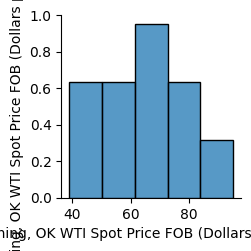

In [25]:
sns.pairplot(df2)

<Axes: xlabel='Date', ylabel='Cushing, OK WTI Spot Price FOB (Dollars per Barrel)'>

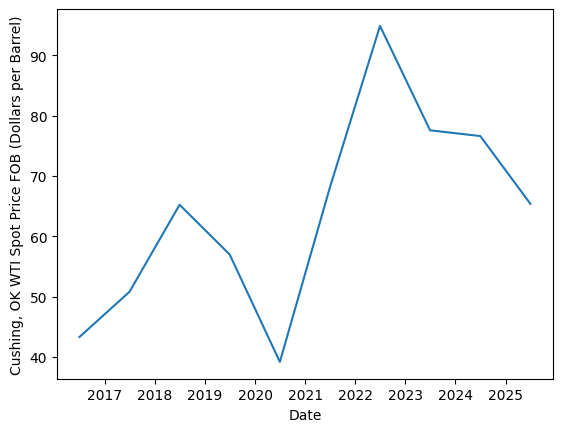

In [31]:
sns.lineplot(df2,x="Date",y='Cushing, OK WTI Spot Price FOB (Dollars per Barrel)')

In [9]:
df['originName'].unique()

array(['Algeria', 'Angola', 'Argentina', 'Brazil', 'Canada',
       'Congo-Kinshasa', 'Colombia', 'Ecuador', 'Gabon', 'Ghana',
       'Guyana', "Cote d'Ivoire", 'Iraq', 'Kuwait', 'Libya', 'Mexico',
       'Nigeria', 'Norway', 'Saudi Arabia', 'Trinidad and Tobago',
       'United Kingdom', 'Venezuela', 'Non-OPEC', 'OPEC', 'Africa',
       'Canada (Region)', 'Europe', 'Middle East', 'Other Americas',
       'World', 'Cameroon', 'United Arab Emirates'], dtype=object)

In [10]:
df.set_index(["period"])

,originId,originName,originType,originTypeName,destinationId,destinationName,destinationType,destinationTypeName,gradeId,gradeName,quantity,quantity-units
period,,,,,,,,,,,,
2026-01,CTY_AG,Algeria,CTY,Country,PP_1,PADD1 (East Coast),PP,Port PADD,LSW,Light Sweet,658,thousand barrels
2026-01,CTY_AG,Algeria,CTY,Country,PS_NJ,New Jersey,PS,Port State,LSW,Light Sweet,658,thousand barrels
2026-01,CTY_AG,Algeria,CTY,Country,PT_1003,"Newark, NJ",PT,Port,LSW,Light Sweet,658,thousand barrels
2026-01,CTY_AG,Algeria,CTY,Country,RF_335,PHILLIPS 66 CO / BAYWAY / NJ,RF,Refinery,LSW,Light Sweet,658,thousand barrels
2026-01,CTY_AG,Algeria,CTY,Country,RP_1,PADD1 (East Coast),RP,Refinery PADD,LSW,Light Sweet,658,thousand barrels
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11,OPN_N,Non-OPEC,OPN,OPEC/non-OPEC,RF_322,HOLLYFRONTIER PUGET SOUND REFNG LLC / PUGET SO...,RF,Refinery,LSO,Light Sour,89,thousand barrels
2025-11,OPN_N,Non-OPEC,OPN,OPEC/non-OPEC,RF_322,HOLLYFRONTIER PUGET SOUND REFNG LLC / PUGET SO...,RF,Refinery,LSW,Light Sweet,56,thousand barrels
2025-11,OPN_N,Non-OPEC,OPN,OPEC/non-OPEC,RF_3238,LOOP LLC / METAIRIE / LA,RF,Refinery,MED,Medium,1,thousand barrels


In [37]:
import_df = df.groupby(['originName'])['quantity']
import_df